# Imports and data statistics

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Load CSV — update path if needed
df_raw = pd.read_csv("form.csv")

# Rename columns to structured names
video_order = ["V1", "V2", "V3", "V4", "V5", "V6"]
dims = ["overall", "eye", "body", "fluency", "voice"]
new_cols = ["timestamp", "age", "gender", "experience"]
for v in video_order:
    for d in dims:
        new_cols.append(f"{v}_{d}")
df_raw.columns = new_cols

# Video metadata
video_meta = {
    "V1": "Baseline (54)",
    "V2": "Eye contact (50)",
    "V3": "Hip+body (49)",
    "V4": "Monotonous (51)",
    "V5": "Filler even (52)",
    "V6": "Filler mid (53)",
}

print(f"Respondents: {len(df_raw)}")
df_raw.head(3)

Respondents: 23


,timestamp,age,gender,experience,V1_overall,V1_eye,V1_body,V1_fluency,V1_voice,V2_overall,...,V5_overall,V5_eye,V5_body,V5_fluency,V5_voice,V6_overall,V6_eye,V6_body,V6_fluency,V6_voice
0,2026/04/19 8:04:00 PM GMT+2,18-25,Muž,Prezentujem len výnimočne (škola / práca),8,8,9,7,9,6,...,5,6,7,5,6,6,6,7,6,7
1,2026/04/19 8:06:53 PM GMT+2,18-25,Muž,Prezentujem len výnimočne (škola / práca),8,10,8,10,9,6,...,5,8,8,2,7,7,8,8,6,8
2,2026/04/19 8:29:46 PM GMT+2,26-35,Muž,Dlhšie som nikde neprezentoval,8,9,8,8,7,7,...,7,6,7,6,6,8,8,8,8,8


In [3]:
# Row with V6 overall=1 but sub-dims all 8-10 (misclick)
# Row with V5 and V6 all identical 9s (no engagement)
# Identify them programmatically:
suspicious = []
for i, row in df_raw.iterrows():
    v6_overall = row["V6_overall"]
    v6_subs = [row[f"V6_{d}"] for d in ["eye", "body", "fluency", "voice"]]
    if v6_overall <= 2 and min(v6_subs) >= 6:
        suspicious.append(i)
        print(f"Row {i}: V6 overall={v6_overall}, subs={v6_subs} — MISCLICK")
    v5_vals = [row[f"V5_{d}"] for d in dims]
    if len(set(v5_vals)) == 1 and v5_vals[0] >= 8:
        suspicious.append(i)
        print(f"Row {i}: V5 all {v5_vals[0]} — UNIFORM (suspicious)")

df = df_raw.drop(index=list(set(suspicious))).reset_index(drop=True)
print(f"\nClean dataset: {len(df)} respondents")


Clean dataset: 23 respondents


# Statistics

In [4]:
records = []
for v in video_order:
    for d in dims:
        col = f"{v}_{d}"
        records.append({
            "video": v,
            "label": video_meta[v],
            "dimension": d,
            "mean": df[col].mean(),
            "std": df[col].std(),
            "median": df[col].median(),
        })

desc = pd.DataFrame(records)

# Pivot: videos as rows, dims as columns (mean)
pivot = desc.pivot(index="label", columns="dimension", values="mean")[dims]
print(pivot.round(2).to_string())

dimension         overall   eye  body  fluency  voice
label                                                
Baseline (54)        7.57  7.87  6.57     8.30   8.87
Eye contact (50)     5.83  5.74  5.39     6.26   7.57
Filler even (52)     4.57  6.30  5.87     3.39   5.83
Filler mid (53)      6.61  7.52  7.13     5.87   7.65
Hip+body (49)        6.52  7.65  5.09     7.00   7.74
Monotonous (51)      4.17  7.13  6.35     5.87   3.39


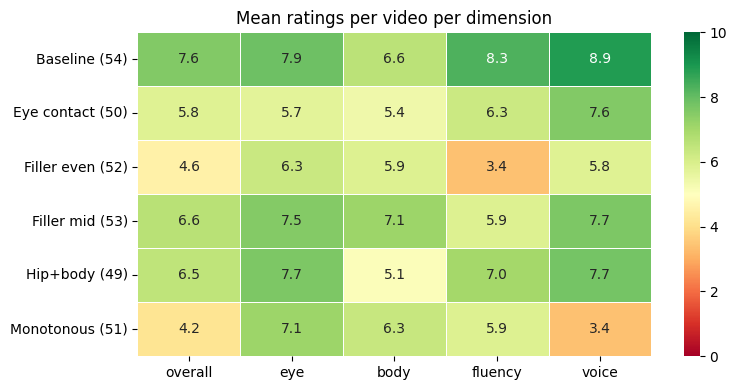

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot.astype(float),
    annot=True, fmt=".1f",
    cmap="RdYlGn", vmin=0, vmax=10,
    ax=ax, linewidths=0.5
)
ax.set_title("Mean ratings per video per dimension")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Hypothesis H1.1: Non-verbal cues are more important than verbal ones
Multiple linear regression across all (respondent × video) observations.
Predictors: eye, body (non-verbal), fluency, voice (verbal).
Outcome: overall rating.

In [8]:
from scipy.stats import ttest_ind

rows_long = []
for v in video_order:
    for _, row in df.iterrows():
        rows_long.append({
            "video": v,
            "overall": row[f"{v}_overall"],
            "eye": row[f"{v}_eye"],
            "body": row[f"{v}_body"],
            "fluency": row[f"{v}_fluency"],
            "voice": row[f"{v}_voice"],
        })
long = pd.DataFrame(rows_long)

X = long[["eye", "body", "fluency", "voice"]].values
y = long["overall"].values

# Standardise so beta coefficients are comparable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from numpy.linalg import lstsq
X_with_intercept = np.column_stack([np.ones(len(X_scaled)), X_scaled])
coefs, _, _, _ = lstsq(X_with_intercept, y, rcond=None)
intercept = coefs[0]
betas = coefs[1:]

print("Standardised beta coefficients:")
for name, b in zip(["eye", "body", "fluency", "voice"], betas):
    print(f"  {name:10s}: {b:.4f}")

nonverbal_beta = (betas[0] + betas[1]) / 2
verbal_beta = (betas[2] + betas[3]) / 2
print(f"\nMean non-verbal beta (eye+body): {nonverbal_beta:.4f}")
print(f"Mean verbal beta (fluency+voice): {verbal_beta:.4f}")
print(f"H1.1 direction supported: {nonverbal_beta > verbal_beta}")

Standardised beta coefficients:
  eye       : 0.3467
  body      : 0.3135
  fluency   : 0.5927
  voice     : 1.1547

Mean non-verbal beta (eye+body): 0.3301
Mean verbal beta (fluency+voice): 0.8737
H1.1 direction supported: False


In [9]:
from scipy.stats import pearsonr

respondent_results = []
for _, row in df.iterrows():
    overalls = [row[f"{v}_overall"] for v in video_order]
    eyes     = [row[f"{v}_eye"]     for v in video_order]
    bodies   = [row[f"{v}_body"]    for v in video_order]
    fluencies= [row[f"{v}_fluency"] for v in video_order]
    voices   = [row[f"{v}_voice"]   for v in video_order]

    r_eye,  _ = pearsonr(eyes,      overalls)
    r_body, _ = pearsonr(bodies,    overalls)
    r_flu,  _ = pearsonr(fluencies, overalls)
    r_voi,  _ = pearsonr(voices,    overalls)
    respondent_results.append({
        "r_eye": r_eye, "r_body": r_body,
        "r_fluency": r_flu, "r_voice": r_voi,
        "r_nonverbal": (r_eye + r_body) / 2,
        "r_verbal":    (r_flu + r_voi) / 2,
    })

corr_df = pd.DataFrame(respondent_results)
print("Mean within-respondent correlations with overall:")
print(corr_df[["r_eye","r_body","r_fluency","r_voice","r_nonverbal","r_verbal"]].mean().round(4))

t_stat, p_val = stats.ttest_rel(corr_df["r_nonverbal"], corr_df["r_verbal"])
print(f"\nPaired t-test (nonverbal vs verbal correlation): t={t_stat:.3f}, p={p_val:.4f}")
print(f"H1.1 supported (p<0.05): {p_val < 0.05}")

Mean within-respondent correlations with overall:
r_eye          0.3987
r_body         0.2030
r_fluency      0.5617
r_voice        0.7026
r_nonverbal    0.3008
r_verbal       0.6322
dtype: float64

Paired t-test (nonverbal vs verbal correlation): t=-5.460, p=0.0000
H1.1 supported (p<0.05): True


# Hypothesis H1.2: Monotonous speaking is stronger predictor than filler words

In [10]:
v4_overall = df["V4_overall"].values
v5_overall = df["V5_overall"].values

t_stat, p_val = stats.ttest_rel(v4_overall, v5_overall)
mean_diff = v4_overall.mean() - v5_overall.mean()

print(f"V4 (monotonous) mean overall: {v4_overall.mean():.2f} ± {v4_overall.std():.2f}")
print(f"V5 (filler even) mean overall: {v5_overall.mean():.2f} ± {v5_overall.std():.2f}")
print(f"Mean difference (V4 - V5): {mean_diff:.2f}")
print(f"Paired t-test: t={t_stat:.3f}, p={p_val:.4f} (one-tailed p={p_val/2:.4f})")
print(f"H1.2 supported (V4 < V5, one-tailed p<0.05): {mean_diff < 0 and p_val/2 < 0.05}")

# Also compare V4 vs V6
v6_overall = df["V6_overall"].values
t2, p2 = stats.ttest_rel(v4_overall, v6_overall)
print(f"\nAlso: V4 vs V6 (filler mid): t={t2:.3f}, p={p2:.4f}, diff={v4_overall.mean()-v6_overall.mean():.2f}")

V4 (monotonous) mean overall: 4.17 ± 2.06
V5 (filler even) mean overall: 4.57 ± 2.26
Mean difference (V4 - V5): -0.39
Paired t-test: t=-1.141, p=0.2660 (one-tailed p=0.1330)
H1.2 supported (V4 < V5, one-tailed p<0.05): False

Also: V4 vs V6 (filler mid): t=-5.279, p=0.0000, diff=-2.43


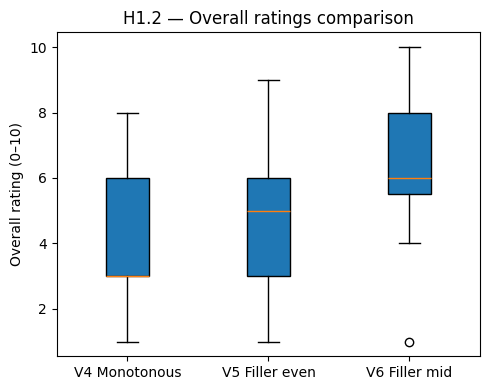

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(
    [v4_overall, v5_overall, v6_overall],
    labels=["V4 Monotonous", "V5 Filler even", "V6 Filler mid"],
    patch_artist=True,
)
ax.set_ylabel("Overall rating (0–10)")
ax.set_title("H1.2 — Overall ratings comparison")
plt.tight_layout()
plt.show()

# Hypothesis 2.1: Concentrated filler words have bigger impact than even

In [12]:
t_stat, p_val = stats.ttest_rel(v6_overall, v5_overall)
mean_diff = v6_overall.mean() - v5_overall.mean()

print(f"V5 (distributed filler) mean: {v5_overall.mean():.2f} ± {v5_overall.std():.2f}")
print(f"V6 (concentrated filler) mean: {v6_overall.mean():.2f} ± {v6_overall.std():.2f}")
print(f"Mean difference (V6 - V5): {mean_diff:.2f}")
print(f"Paired t-test: t={t_stat:.3f}, p={p_val:.4f} (one-tailed p={p_val/2:.4f})")
print(f"H2.1 as stated (V6 < V5): {mean_diff < 0}")
print(f"Reversed finding (V5 < V6, distributed worse): {mean_diff > 0}")

# Per-respondent direction
n_v6_worse = (v6_overall < v5_overall).sum()
n_v5_worse = (v5_overall < v6_overall).sum()
print(f"\nRespondents: V6<V5 (concentrated worse): {n_v6_worse}, V5<V6 (distributed worse): {n_v5_worse}")

V5 (distributed filler) mean: 4.57 ± 2.26
V6 (concentrated filler) mean: 6.61 ± 2.04
Mean difference (V6 - V5): 2.04
Paired t-test: t=4.145, p=0.0004 (one-tailed p=0.0002)
H2.1 as stated (V6 < V5): False
Reversed finding (V5 < V6, distributed worse): True

Respondents: V6<V5 (concentrated worse): 1, V5<V6 (distributed worse): 21


In [14]:
v5_fluency = df["V5_fluency"].values
v6_fluency = df["V6_fluency"].values

t_stat, p_val = stats.ttest_rel(v6_fluency, v5_fluency)
print(f"V5 fluency mean: {v5_fluency.mean():.2f}")
print(f"V6 fluency mean: {v6_fluency.mean():.2f}")
print(f"Paired t-test on fluency: t={t_stat:.3f}, p={p_val:.4f}")

V5 fluency mean: 3.39
V6 fluency mean: 5.87
Paired t-test on fluency: t=6.092, p=0.0000


In [15]:
def cohens_d(a, b):
    diff = np.mean(a) - np.mean(b)
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled_std

print("Cohen's d effect sizes:")
print(f"  H1.2 V4 vs V5 overall: d = {cohens_d(v4_overall, v5_overall):.3f}")
print(f"  H1.2 V4 vs V6 overall: d = {cohens_d(v4_overall, v6_overall):.3f}")
print(f"  H2.1 V6 vs V5 overall: d = {cohens_d(v6_overall, v5_overall):.3f}")
print(f"  H2.1 V6 vs V5 fluency: d = {cohens_d(v6_fluency, v5_fluency):.3f}")
print("\n  |d|: 0.2=small, 0.5=medium, 0.8=large")

Cohen's d effect sizes:
  H1.2 V4 vs V5 overall: d = -0.177
  H1.2 V4 vs V6 overall: d = -1.163
  H2.1 V6 vs V5 overall: d = 0.928
  H2.1 V6 vs V5 fluency: d = 1.239

  |d|: 0.2=small, 0.5=medium, 0.8=large


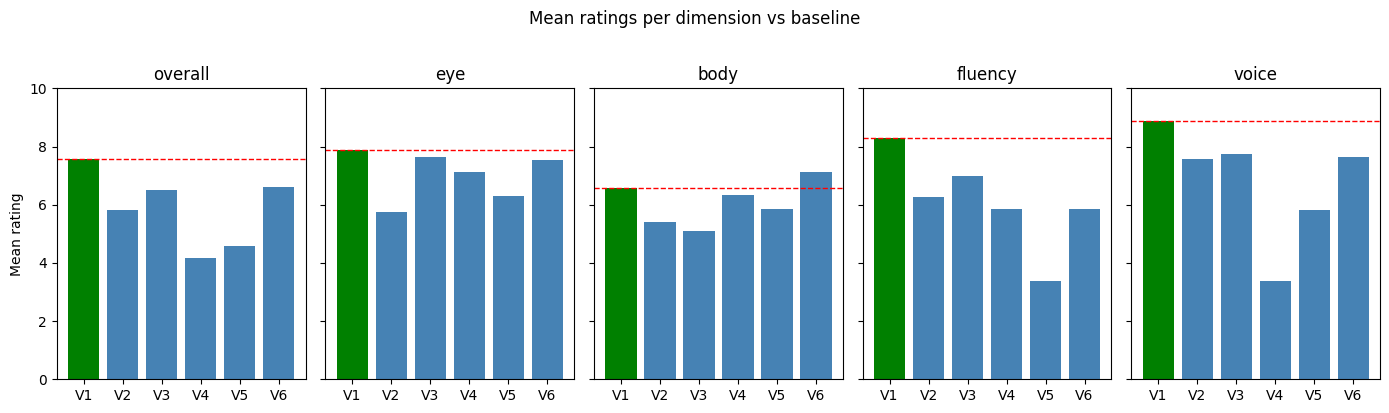

In [16]:
baseline_means = {d: df[f"V1_{d}"].mean() for d in dims}

fig, axes = plt.subplots(1, len(dims), figsize=(14, 4), sharey=True)
for ax, d in zip(axes, dims):
    means = [df[f"{v}_{d}"].mean() for v in video_order]
    colors = ["green" if v == "V1" else "steelblue" for v in video_order]
    ax.bar(video_order, means, color=colors)
    ax.axhline(baseline_means[d], color="red", linestyle="--", linewidth=1, label="baseline")
    ax.set_title(d)
    ax.set_ylim(0, 10)
    ax.set_xlabel("")
axes[0].set_ylabel("Mean rating")
fig.suptitle("Mean ratings per dimension vs baseline", y=1.02)
plt.tight_layout()
plt.show()